<a href="https://colab.research.google.com/github/AlekhyaGangopadhyay/CodeAlphaInternship/blob/main/Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/CodeAlphaInternship/Datasets/german_credit_data.csv')
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [4]:
columns=df.columns
print(columns)

Index(['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit',
       'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred',
       'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit'],
      dtype='object')


In [7]:
new_column_names = {
    'laufkont': 'Checking account status',
    'laufzeit': 'Duration (in months)',
    'moral': 'Credit history',
    'verw': 'Purpose (of loan)',
    'hoehe': 'Credit amount',
    'sparkont': 'Savings account/bonds',
    'beszeit': 'Employment duration',
    'rate': 'Installment rate (as % of income)',
    'famges': 'Personal status & gender',
    'buerge': 'Guarantors',
    'wohnzeit': 'Duration in current residence',
    'verm': 'Property / assets',
    'alter': 'Age',
    'weitkred': 'Other installment plans',
    'wohn': 'Housing',
    'bishkred': 'Number of existing credits',
    'beruf': 'Job / occupation',
    'pers': 'Number of people liable (dependents)',
    'telef': 'Telephone availability',
    'gastarb': 'Foreign worker',
    'kredit': 'Credit risk (target variable)'
}
df_new = df.rename(columns=new_column_names)
print("Columns renamed successfully. Displaying first 5 rows with new names:")
display(df_new.head())

Columns renamed successfully. Displaying first 5 rows with new names:


,Checking account status,Duration (in months),Credit history,Purpose (of loan),Credit amount,Savings account/bonds,Employment duration,Installment rate (as % of income),Personal status & gender,Guarantors,...,Property / assets,Age,Other installment plans,Housing,Number of existing credits,Job / occupation,Number of people liable (dependents),Telephone availability,Foreign worker,Credit risk (target variable)
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [9]:
columns_new=df_new.columns

In [11]:
print(columns_new)

Index(['Checking account status', 'Duration (in months)', 'Credit history',
       'Purpose (of loan)', 'Credit amount', 'Savings account/bonds',
       'Employment duration', 'Installment rate (as % of income)',
       'Personal status & gender', 'Guarantors',
       'Duration in current residence', 'Property / assets', 'Age',
       'Other installment plans', 'Housing', 'Number of existing credits',
       'Job / occupation', 'Number of people liable (dependents)',
       'Telephone availability', 'Foreign worker',
       'Credit risk (target variable)'],
      dtype='object')


In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [14]:
le = LabelEncoder()
for col in columns_new:
    if df_new[col].dtype == 'object':
        df_new[col] = le.fit_transform(df_new[col])

In [16]:
output_path = '/content/drive/My Drive/CodeAlphaInternship/Datasets/german_credit_data_renamed.csv'
df_new.to_csv(output_path, index=False)
print(f"DataFrame saved to {output_path}")

DataFrame saved to /content/drive/My Drive/CodeAlphaInternship/Datasets/german_credit_data_renamed.csv


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

X = df_new.drop('Credit risk (target variable)', axis=1)
y = df_new['Credit risk (target variable)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression     0.775   0.810458  0.885714  0.846416  0.808571
1        Decision Tree     0.695   0.776224  0.792857  0.784452  0.629762
2        Random Forest     0.800   0.812500  0.928571  0.866667  0.814405


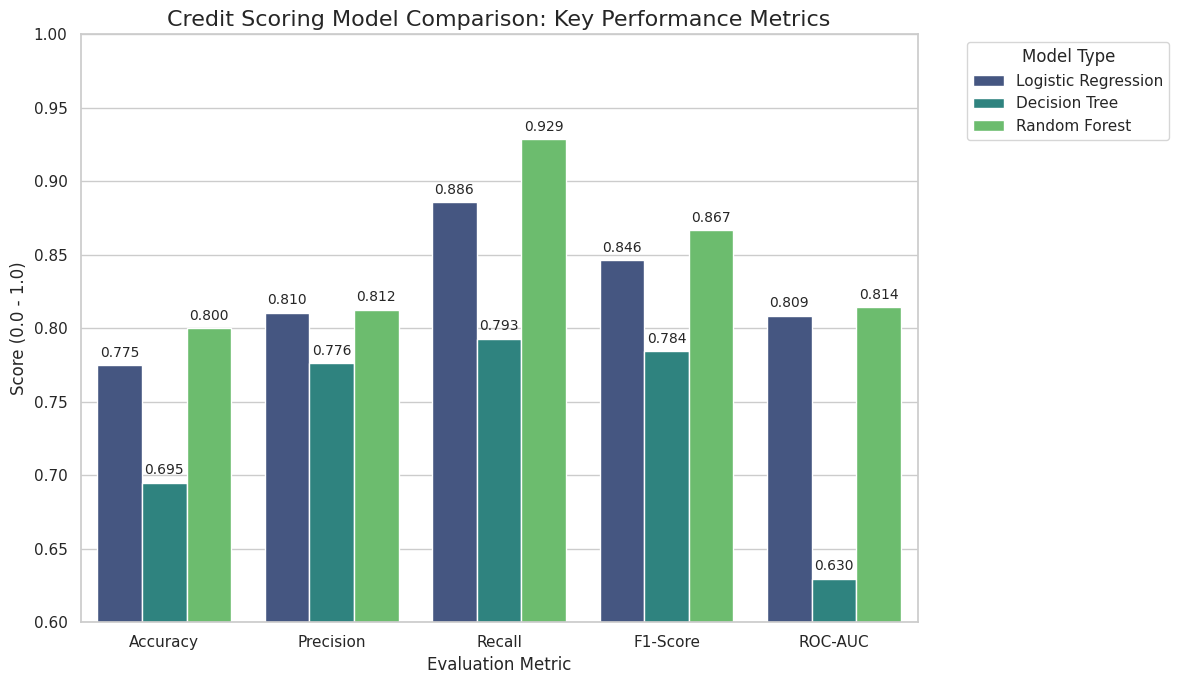

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results)
df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))
plot = sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="viridis")

plt.title("Credit Scoring Model Comparison: Key Performance Metrics", fontsize=16)
plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.legend(title="Model Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.6, 1.0)
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_results.png')

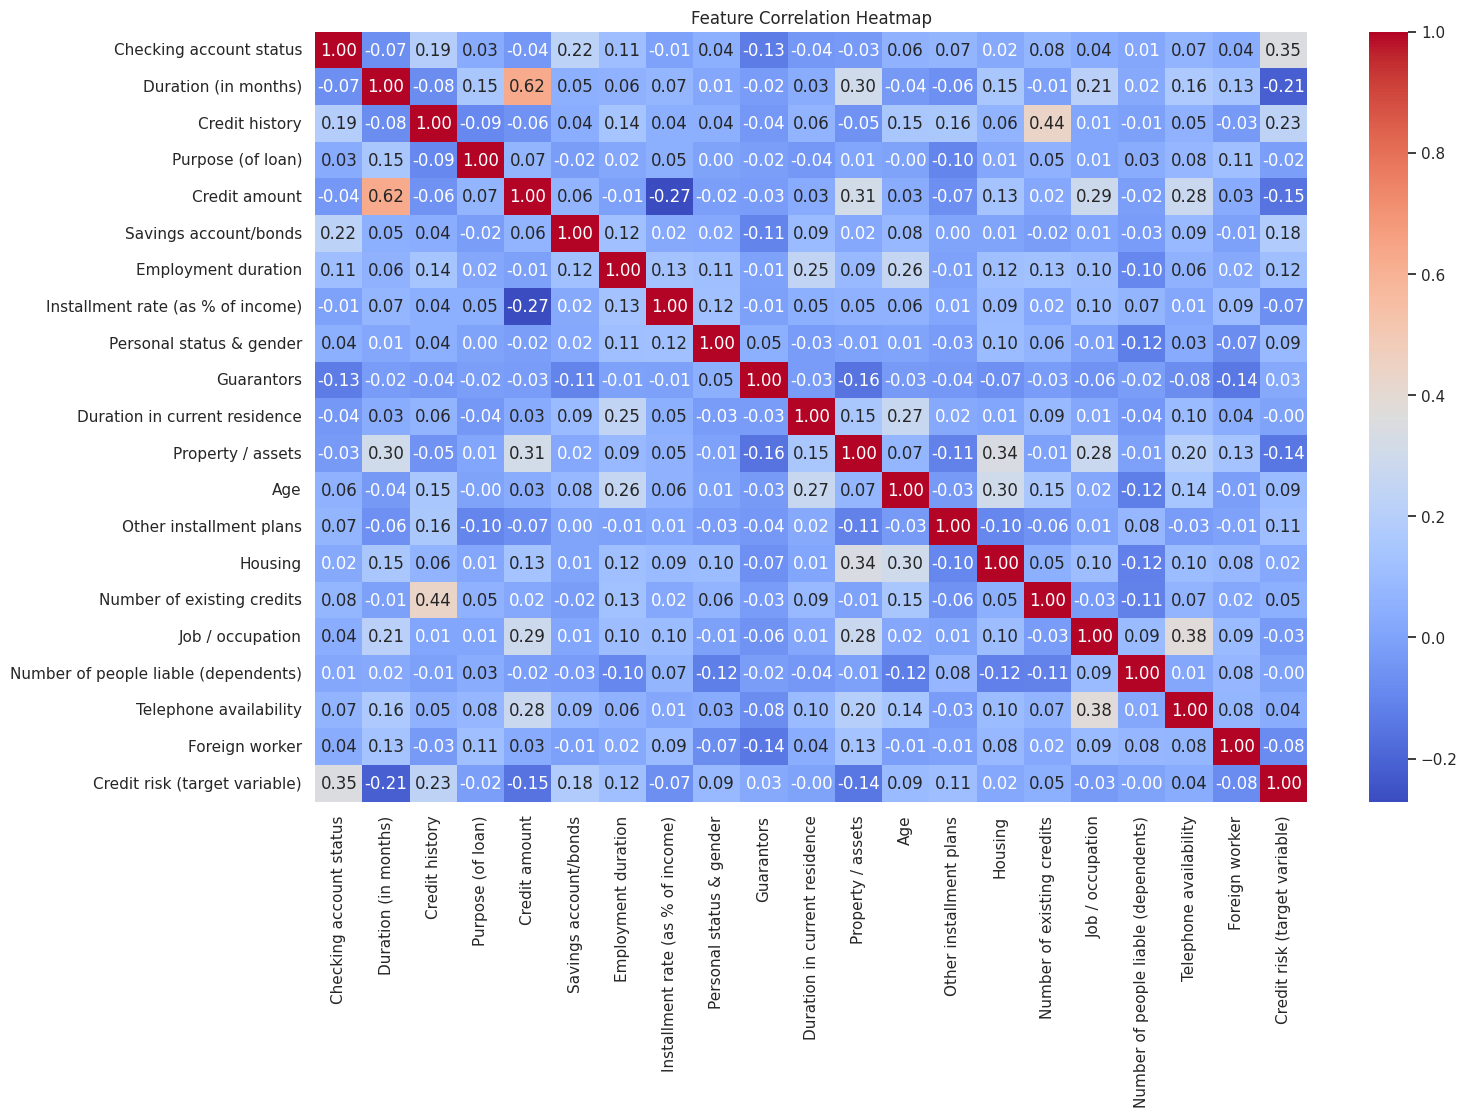

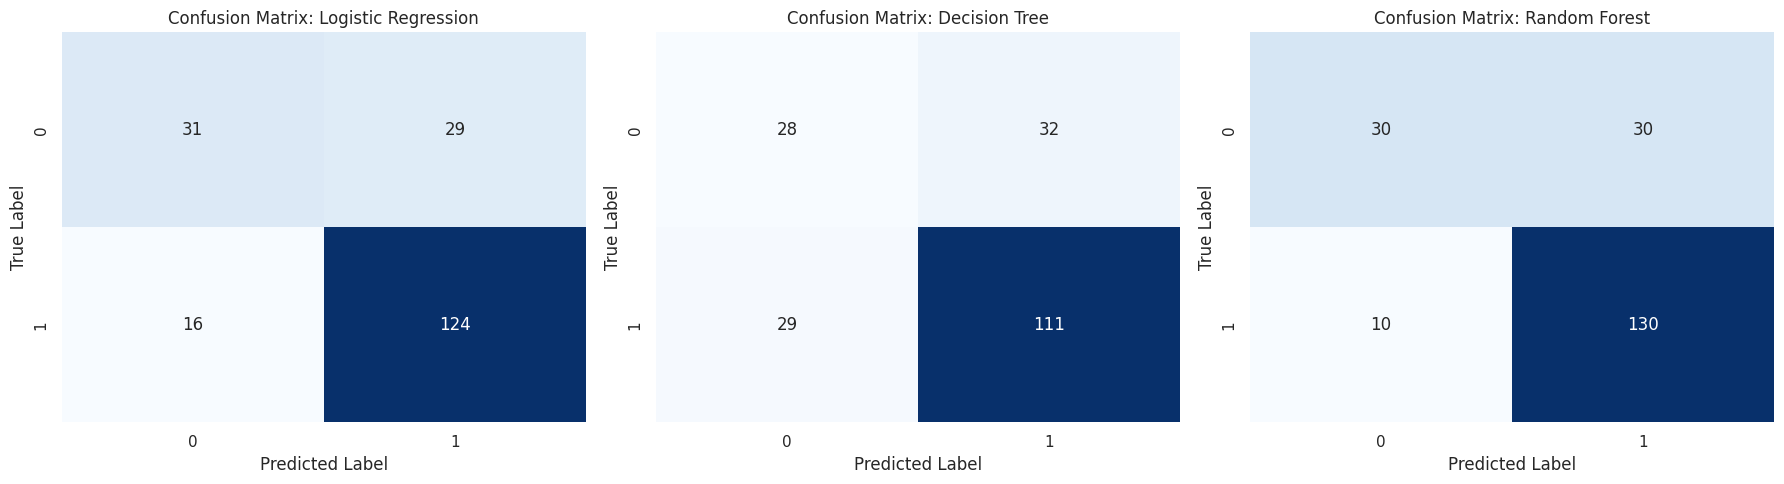

In [21]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(16, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices_heatmap.png')